In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import date, timedelta

Synthetic data saved to /content/synthetic_data
Number of jumps: 4
Parameters: {'mu': 0.05, 'sigma': 0.2, 'lambda_jump': 2.0, 'mu_jump': 0.0, 'sigma_jump': 0.1, 'T': 1.0, 'dt': 0.0001, 'n_steps': 10000.0, 'noise_scale': 0.001, 'seed': 42.0}


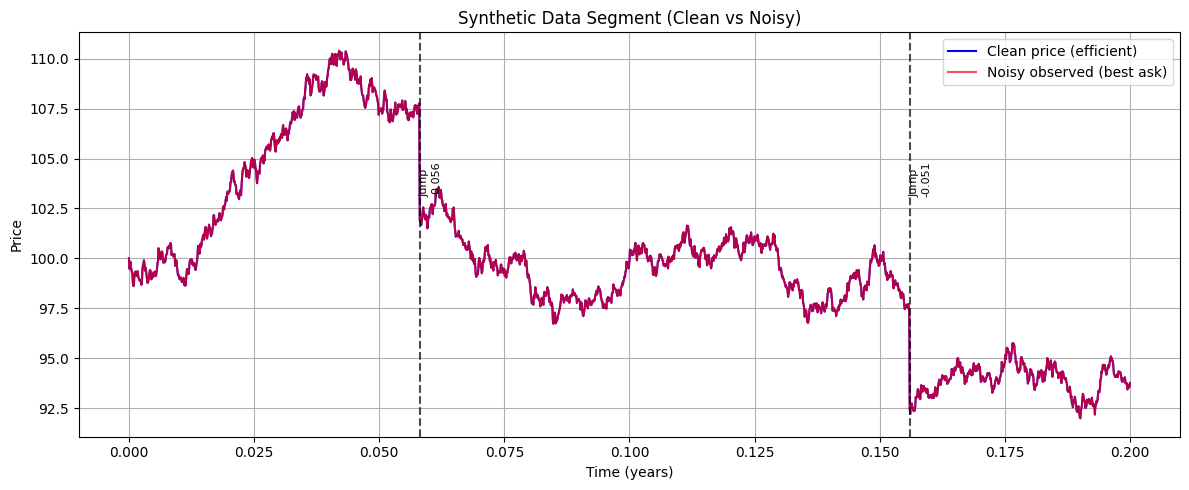

In [ ]:
#!/usr/bin/env python3
"""
Step 0: Synthetic data generation for jump-diffusion models with LOMN noise.
(Adapted for Google Colab)
"""

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import norm, expon, poisson

# ------------------------------
# 1. Simulation parameters
# ------------------------------
mu = 0.05          # drift (annualized)
sigma = 0.2        # volatility (annualized)
lambda_jump = 2.0  # jump intensity per year
mu_jump = 0.0      # mean of log-jump size
sigma_jump = 0.1   # std of log-jump size

T = 1.0            # total time in years
n_steps = 10000    # number of time steps
dt = T / n_steps
t = np.linspace(0, T, n_steps + 1)

# Noise parameters (LOMN: one-sided exponential)
noise_scale = 0.001

# Output directory (Colab-friendly)
output_dir = Path("/content/synthetic_data")
output_dir.mkdir(exist_ok=True)

np.random.seed(42)

# ------------------------------
# 2. Generate jump times and sizes
# ------------------------------
n_jumps = np.random.poisson(lambda_jump * T)
jump_times = np.sort(np.random.uniform(0, T, n_jumps))
log_jump_sizes = np.random.normal(mu_jump, sigma_jump, n_jumps)
jump_factors = np.exp(log_jump_sizes) - 1

# ------------------------------
# 3. Simulate clean price path (GBM + jumps)
# ------------------------------
S = np.zeros(n_steps + 1)
S[0] = 100.0
dW = np.random.normal(0, np.sqrt(dt), n_steps)
jump_mask = np.zeros(n_steps, dtype=bool)
jump_sizes_at_steps = np.zeros(n_steps)

for i in range(n_steps):
    dS_cont = mu * dt + sigma * dW[i]
    t_cur = t[i]
    t_next = t[i+1]
    idx = np.where((jump_times >= t_cur) & (jump_times < t_next))[0]
    if len(idx) > 0:
        jump_contrib = np.sum(jump_factors[idx])
        dS_cont += jump_contrib
        jump_mask[i] = True
        jump_sizes_at_steps[i] = jump_contrib
    S[i+1] = S[i] * (1 + dS_cont)

clean_df = pd.DataFrame({'time': t, 'price_clean': S})

# ------------------------------
# 4. Add one-sided LOMN noise
# ------------------------------
epsilon = np.random.exponential(scale=noise_scale, size=n_steps + 1)
noisy_price = S + epsilon
noisy_df = pd.DataFrame({'time': t, 'price_noisy': noisy_price, 'epsilon': epsilon})

# ------------------------------
# 5. Record true jumps
# ------------------------------
jump_df = pd.DataFrame({
    'jump_time': jump_times,
    'log_jump_size': log_jump_sizes,
    'rel_jump_size': jump_factors
})

# ------------------------------
# 6. Save all data
# ------------------------------
clean_df.to_csv(output_dir / 'clean_path.csv', index=False)
noisy_df.to_csv(output_dir / 'noisy_path.csv', index=False)
jump_df.to_csv(output_dir / 'true_jumps.csv', index=False)

clean_df.to_hdf(output_dir / 'synthetic_data.h5', key='clean', mode='w')
noisy_df.to_hdf(output_dir / 'synthetic_data.h5', key='noisy', mode='a')
jump_df.to_hdf(output_dir / 'synthetic_data.h5', key='jumps', mode='a')

params = {
    'mu': mu, 'sigma': sigma, 'lambda_jump': lambda_jump,
    'mu_jump': mu_jump, 'sigma_jump': sigma_jump,
    'T': T, 'dt': dt, 'n_steps': n_steps,
    'noise_scale': noise_scale, 'seed': 42
}
pd.Series(params).to_csv(output_dir / 'parameters.csv')

print(f"Synthetic data saved to {output_dir}")
print(f"Number of jumps: {n_jumps}")

# ------------------------------
# 7. Data loading utilities
# ------------------------------
def load_synthetic_data(data_dir='/content/synthetic_data'):
    clean = pd.read_csv(Path(data_dir) / 'clean_path.csv')
    noisy = pd.read_csv(Path(data_dir) / 'noisy_path.csv')
    jumps = pd.read_csv(Path(data_dir) / 'true_jumps.csv')
    params = pd.read_csv(Path(data_dir) / 'parameters.csv', index_col=0).squeeze().to_dict()
    return clean, noisy, jumps, params

def plot_sample_paths(clean_df, noisy_df, jump_df, t_start=0, t_end=0.2):
    mask = (clean_df['time'] >= t_start) & (clean_df['time'] <= t_end)
    times = clean_df.loc[mask, 'time'].values
    clean_vals = clean_df.loc[mask, 'price_clean'].values
    noisy_vals = noisy_df.loc[mask, 'price_noisy'].values

    jumps_in_interval = jump_df[(jump_df['jump_time'] >= t_start) & (jump_df['jump_time'] <= t_end)]

    plt.figure(figsize=(12, 5))
    plt.plot(times, clean_vals, 'b-', label='Clean price (efficient)')
    plt.plot(times, noisy_vals, 'r-', alpha=0.7, label='Noisy observed (best ask)')
    for _, row in jumps_in_interval.iterrows():
        plt.axvline(x=row['jump_time'], color='k', linestyle='--', alpha=0.7)
        plt.text(row['jump_time'], clean_vals.max()*0.95, f"Jump\n{row['rel_jump_size']:.3f}",
                 rotation=90, verticalalignment='top', fontsize=8)
    plt.xlabel('Time (years)')
    plt.ylabel('Price')
    plt.title('Synthetic Data Segment (Clean vs Noisy)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ------------------------------
# 8. Quick test (only in interactive mode)
# ------------------------------
if __name__ == "__main__":
    clean, noisy, jumps, params = load_synthetic_data()
    print("Parameters:", params)
    plot_sample_paths(clean, noisy, jumps, t_start=0, t_end=0.2)

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm, expon, gumbel_r
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# CONFIGURATION & CONSTANTS
# =============================================================================
PI = np.pi
C_LOMN = PI / (2 * (PI - 2))  # ≈ 1.1781 for LOMN volatility estimator
DEFAULT_CORRECTION = 0.954     # Finite-sample correction factor
DEFAULT_K = 200                # Window size for local volatility estimation
DEFAULT_N = 23400              # Observations per day (~1-second)
DEFAULT_H_FACTOR = 1.2         # Bandwidth factor: h = factor * n^(-2/3)

# =============================================================================
# 1. SIMULATION OF EFFICIENT PRICE WITH STOCHASTIC VOLATILITY
# =============================================================================

def simulate_X(T=1, n=DEFAULT_N, seed=None):
    """
    Simulate efficient log-price X_t and spot volatility sigma_t.

    Model:
        dX_t = v_t * sigma_t * dW_t
        d(sigma_t^2) = kappa*(theta - sigma_t^2)*dt + xi*sigma_t*dB_t
        v_t = (1.2 - 0.2*sin(0.75*pi*t)) * 0.01
        d[W,B]_t = rho*dt with rho = -0.5

    Parameters:
        T: Time horizon (default: 1 day)
        n: Number of discretization steps
        seed: Random seed for reproducibility

    Returns:
        X: Efficient price path (n+1 array)
        sigma: Spot volatility path (n+1 array)
        v: Leverage function values (n+1 array)
        t: Time grid (n+1 array)
    """
    if seed is not None:
        np.random.seed(seed)

    dt = T / n
    t = np.linspace(0, T, n + 1)

    # Precompute time-varying leverage function v_t
    v = (1.2 - 0.2 * np.sin(0.75 * PI * t)) * 0.01

    # CIR-type volatility process parameters
    kappa, theta, xi = 0.0162, 0.8465, 0.117
    sigma2 = np.full(n + 1, theta)  # Start at stationary mean
    sigma = np.sqrt(sigma2)

    # Correlated Brownian motions via Cholesky
    rho = -0.5
    cov = np.array([[1.0, rho], [rho, 1.0]])
    L = np.linalg.cholesky(cov)

    X = np.zeros(n + 1)

    for i in range(n):
        # Generate correlated increments
        dWdB = L @ np.random.normal(0, np.sqrt(dt), 2)
        dW, dB = dWdB[0], dWdB[1]

        # Euler-Maruyama update for volatility (with reflection boundary)
        sigma2[i + 1] = sigma2[i] + kappa * (theta - sigma2[i]) * dt + xi * sigma[i] * dB
        sigma2[i + 1] = max(sigma2[i + 1], 1e-8)  # Prevent negative variance
        sigma[i + 1] = np.sqrt(sigma2[i + 1])

        # Price update
        X[i + 1] = X[i] + v[i] * sigma[i] * dW

    return X, sigma, v, t


def add_jump(X, jump_time, jump_size, n=DEFAULT_N):
    """
    Add a jump at specified time index.

    Parameters:
        X: Price path array
        jump_time: Time in [0, T] where jump occurs
        jump_size: Magnitude of jump (positive or negative)
        n: Number of observations (for index conversion)

    Returns:
        X_jump: Price path with jump added
    """
    X_jump = X.copy()
    idx = int(np.round(jump_time * n))
    idx = np.clip(idx, 0, len(X_jump) - 1)
    X_jump[idx:] += jump_size
    return X_jump


# =============================================================================
# 2. LOMN OBSERVATIONS AND BLOCK MINIMA
# =============================================================================

def generate_LOMN_observations(X, q, noise_dist='exponential', seed=None):
    """
    Generate observations with one-sided microstructure noise.

    Y_i = X_{i/n} + q * epsilon_i,  epsilon_i ~ Exp(1)

    Parameters:
        X: Efficient price path
        q: Noise scale parameter
        noise_dist: Currently only 'exponential' supported
        seed: Random seed

    Returns:
        Y: Observed price path with noise
    """
    if seed is not None:
        np.random.seed(seed)

    if noise_dist == 'exponential':
        eps = np.random.exponential(scale=1.0, size=len(X))
    else:
        raise ValueError(f"Unsupported noise distribution: {noise_dist}")

    return X + q * eps


def block_minima(Y, h, n):
    """
    Compute block minima for LOMN model.

    Parameters:
        Y: Observed price path
        h: Block length in time units
        n: Total number of observations

    Returns:
        minima: Array of block minima
        block_size: Number of observations per block
        n_blocks: Number of complete blocks
    """
    block_size = max(1, int(np.round(h * n)))
    n_blocks = len(Y) // block_size

    # Vectorized block minima computation
    Y_trim = Y[:n_blocks * block_size]
    minima = Y_trim.reshape(n_blocks, block_size).min(axis=1)

    return minima, block_size, n_blocks


def spot_volatility_LOMN(minima, block_size, n, K=DEFAULT_K, correction=DEFAULT_CORRECTION,
                         return_indices=False, verbose=False):
    """
    Estimate spot volatility using block minima differences.

    Formula: σ̂² = c × h⁻¹ × (1/K) × Σ(Δmⱼ)²
    where c = π/(2(π-2)) ≈ 1.1781

    Parameters:
        minima: Array of block minima
        block_size: Observations per block
        n: Total observations
        K: Window size for local averaging
        correction: Finite-sample correction factor
        return_indices: If True, return global block indices for estimates
        verbose: If True, print diagnostic information

    Returns:
        sigma2_hat: Estimated volatility squared (valid entries only)
        global_indices: Corresponding block indices (if return_indices=True)
    """
    h = block_size / n
    n_diff = len(minima) - 1

    if n_diff < K:
        if verbose:
            print(f"Warning: Not enough blocks (n_diff={n_diff} < K={K})")
        return (np.array([]), np.array([])) if return_indices else np.array([])

    # Compute differences between consecutive minima
    diff = np.diff(minima)

    # Pre-allocate full array for volatility estimates
    sigma2_full = np.zeros(n_diff)

    # Rolling window computation (vectorized where possible)
    half_K = K // 2
    for i in range(half_K, n_diff - half_K):
        window = diff[i - half_K : i + half_K + 1]  # Include both endpoints
        # Correct scaling: h⁻¹ = n / block_size
        sigma2_full[i] = C_LOMN * np.mean(window**2) / h

    # Apply finite-sample correction
    sigma2_full *= correction

    # Extract valid (positive) estimates
    valid_mask = sigma2_full > 1e-10
    sigma2_hat = sigma2_full[valid_mask]
    global_indices = np.where(valid_mask)[0]  # Block indices in original minima array

    if verbose and len(sigma2_hat) > 0:
        print(f"Volatility estimates: {len(sigma2_hat)} valid, "
              f"range=[{np.sqrt(sigma2_hat.min()):.4f}, {np.sqrt(sigma2_hat.max()):.4f}]")

    if return_indices:
        return sigma2_hat, global_indices
    return sigma2_hat


# =============================================================================
# 3. GLOBAL TEST STATISTIC (BHR)
# =============================================================================

def gumbel_normalization(T_raw, M, method='standard'):
    """
    Normalize test statistic to converge to standard Gumbel.

    Parameters:
        T_raw: Raw maximum statistic
        M: Number of independent comparisons (≈ n_blocks - 1)
        method: Normalization method ('standard' or 'paper')

    Returns:
        norm_stat: Normalized statistic ~ Gumbel(0, 1) asymptotically
    """
    if M < 2:
        return -np.inf

    if method == 'standard':
        # Standard extreme value normalization
        a_n = 1.0 / np.sqrt(2 * np.log(M))
        b_n = np.sqrt(2 * np.log(M)) - (np.log(np.log(M)) + np.log(4 * PI)) / (2 * np.sqrt(2 * np.log(M)))
        return (T_raw - b_n) / a_n
    else:
        # Alternative form from some papers
        B_n = 2 * np.log(M) - np.log(PI * np.log(M))
        return T_raw * np.sqrt(2 * np.log(M)) - B_n


def global_test_statistic(Y, n, h, K=DEFAULT_K, correction=DEFAULT_CORRECTION,
                         verbose=False, return_components=False):
    """
    Compute normalized global test statistic for jump detection.

    T_BHR = max_k |m_k - m_{k-1}| / σ̂_k
    Normalized: (T_BHR - b_M) / a_M → Gumbel(0,1)

    Parameters:
        Y: Observed price path
        n: Number of observations
        h: Block length
        K: Volatility estimation window
        correction: Finite-sample correction
        verbose: Print diagnostics
        return_components: Return intermediate values for debugging

    Returns:
        norm_stat: Normalized test statistic
        (Optional) dict with T_raw, sigma_hat, etc. if return_components=True
    """
    # Step 1: Compute block minima
    minima, block_size, n_blocks = block_minima(Y, h, n)
    if n_blocks < 3:
        return -np.inf, {} if return_components else -np.inf

    # Step 2: Compute absolute differences
    diff = np.abs(np.diff(minima))  # Length: n_blocks - 1
    M = len(diff)  # Number of comparisons

    # Step 3: Estimate volatility WITH index tracking
    result = spot_volatility_LOMN(minima, block_size, n, K, correction,
                                  return_indices=True, verbose=verbose)
    if len(result) == 0 or len(result[0]) == 0:
        return -np.inf, {} if return_components else -np.inf

    sigma2_hat, vol_indices = result
    sigma_hat = np.sqrt(sigma2_hat)

    if verbose:
        print(f"Blocks: {n_blocks}, Comparisons: {M}, Valid vol estimates: {len(sigma_hat)}")

    # Step 4: Align differences with volatility estimates
    # vol_indices are indices in the diff array where we have valid σ̂
    if len(vol_indices) == 0:
        return -np.inf, {} if return_components else -np.inf

    diff_aligned = diff[vol_indices]

    # Step 5: Compute raw test statistic
    ratios = diff_aligned / sigma_hat
    T_raw = np.max(ratios)
    max_idx = vol_indices[np.argmax(ratios)]

    # Step 6: Normalize to Gumbel
    norm_stat = gumbel_normalization(T_raw, M)

    if verbose:
        print(f"T_raw={T_raw:.4f}, M={M}, norm_stat={norm_stat:.4f}, "
              f"critical={gumbel_critical_value(0.05):.4f}")

    if return_components:
        return norm_stat, {
            'T_raw': T_raw,
            'M': M,
            'sigma_hat': sigma_hat,
            'diff_aligned': diff_aligned,
            'max_block_idx': max_idx,
            'estimated_time': (max_idx + 1) * h
        }

    return norm_stat


def gumbel_critical_value(alpha=0.05):
    """Critical value for standard Gumbel at significance level alpha."""
    return -np.log(-np.log(1 - alpha))


# =============================================================================
# 4. LEE-MYKLAND TEST FOR MMN (BENCHMARK)
# =============================================================================

def generate_MMN_observations(X, q, seed=None):
    """Generate observations with two-sided Gaussian microstructure noise."""
    if seed is not None:
        np.random.seed(seed)
    eps = np.random.normal(0, 1, size=len(X))
    return X + q * eps


def block_averages(Y, h, n):
    """Compute blockwise averages for MMN model."""
    block_size = max(1, int(np.round(h * n)))
    n_blocks = len(Y) // block_size
    Y_trim = Y[:n_blocks * block_size]
    averages = Y_trim.reshape(n_blocks, block_size).mean(axis=1)
    return averages, block_size, n_blocks


def spot_volatility_MMN(averages, block_size, n, K=DEFAULT_K):
    """
    Estimate volatility for MMN using block average differences.

    For Gaussian noise: Var(avg_i - avg_{i-1}) ≈ 2σ²/(n·h) + O(h)
    """
    h = block_size / n
    diff = np.diff(averages)
    n_diff = len(diff)

    if n_diff < K:
        return np.array([]), np.array([])

    sigma2_full = np.zeros(n_diff)
    half_K = K // 2

    for i in range(half_K, n_diff - half_K):
        window = diff[i - half_K : i + half_K + 1]
        # For MMN: σ̂² ≈ (n·h/2) × mean((Δavg)²)
        sigma2_full[i] = 0.5 * np.mean(window**2) / h

    valid_mask = sigma2_full > 1e-10
    return sigma2_full[valid_mask], np.where(valid_mask)[0]


def LM_test_statistic(Y, n, h, K=20, verbose=False):
    """
    Compute Lee-Mykland test statistic for MMN.

    T_LM = max_i |avg_i - avg_{i-1}| / σ̂_i
    """
    avg, block_size, n_blocks = block_averages(Y, h, n)
    if n_blocks < 3:
        return -np.inf

    diff = np.abs(np.diff(avg))
    sigma2_hat, vol_indices = spot_volatility_MMN(avg, block_size, n, K)

    if len(sigma2_hat) == 0:
        return -np.inf

    sigma_hat = np.sqrt(sigma2_hat)
    diff_aligned = diff[vol_indices]

    T_raw = np.max(diff_aligned / sigma_hat)

    if verbose:
        print(f"LM: T_raw={T_raw:.4f}, critical≈3.2")

    return T_raw


def lm_critical_value(n, alpha=0.05):
    """
    Approximate Lee-Mykland critical value.

    More accurate: c_alpha = sqrt(-2*log(-log(1-alpha)))
    For alpha=0.05: ≈ 2.97, but finite-sample adjustments push to ~3.2-3.5
    """
    # Asymptotic critical value
    c_alpha = np.sqrt(-2 * np.log(-np.log(1 - alpha)))
    # Finite-sample adjustment (empirical)
    adjustment = 0.2 + 0.5 / np.log(n)
    return c_alpha + adjustment


# =============================================================================
# 5. LOCAL TEST (COROLLARY 2.2)
# =============================================================================

def local_test_statistic(Y, tau, n, h, K=20, correction=DEFAULT_CORRECTION, verbose=False):
    """
    Compute local test statistic at time tau.

    S = h^(-1/2) × | min_after/σ_after - min_before/σ_before |

    Under H0: S → |Z₁ - Z₂| where Z₁, Z₂ ~ Half-Normal(0,1)
    """
    block_size = max(1, int(np.round(h * n)))

    # Identify blocks surrounding tau
    k = int(np.floor(tau / h))  # Block index containing tau
    k = np.clip(k, 1, (len(Y) // block_size) - 2)  # Ensure valid neighbors

    # Extract data for before/after blocks
    start_before = (k - 1) * block_size
    end_before = k * block_size
    start_after = k * block_size
    end_after = (k + 1) * block_size

    if end_after > len(Y):
        if verbose:
            print(f"Warning: tau={tau} too close to end")
        return 0.0

    Y_before = Y[start_before:end_before]
    Y_after = Y[start_after:end_after]

    min_before = np.min(Y_before)
    min_after = np.min(Y_after)

    # Estimate volatility in neighborhood using small K for locality
    minima, _, n_blocks = block_minima(Y, h, n)

    # Get volatility estimate for block k-1 (before)
    sigma2_before, idx_before = spot_volatility_LOMN(minima, block_size, n, K, correction,
                                                      return_indices=True)
    # Get volatility estimate for block k (after)
    sigma2_after, idx_after = spot_volatility_LOMN(minima, block_size, n, K, correction,
                                                    return_indices=True)

    # Find volatility at specific block indices
    def get_vol_at_block(sigma2_est, block_idx, valid_indices):
        """Lookup volatility estimate for a specific block index."""
        pos = np.searchsorted(valid_indices, block_idx)
        if pos < len(valid_indices) and valid_indices[pos] == block_idx:
            return np.sqrt(sigma2_est[pos])
        return None  # No estimate available

    sigma_before = get_vol_at_block(sigma2_before, k - 1, idx_before)
    sigma_after = get_vol_at_block(sigma2_after, k, idx_after)

    # Fallback to global median if local estimate unavailable
    if sigma_before is None:
        sigma_before = np.sqrt(np.median(sigma2_before)) if len(sigma2_before) > 0 else 1.0
    if sigma_after is None:
        sigma_after = np.sqrt(np.median(sigma2_after)) if len(sigma2_after) > 0 else 1.0

    # Compute test statistic
    S = np.abs(min_after / sigma_after - min_before / sigma_before) / np.sqrt(h)

    if verbose:
        print(f"Local test at tau={tau:.3f}: S={S:.4f}, σ_before={sigma_before:.4f}, σ_after={sigma_after:.4f}")

    return S


def halfnorm_diff_critical_value(alpha=0.05, nsim=100000):
    """
    Critical value for |Z₁ - Z₂| where Z₁, Z₂ ~ Half-Normal(0,1) independent.

    P(|Z₁ - Z₂| > c) = alpha
    """
    Z1 = np.abs(np.random.normal(0, 1, size=nsim))
    Z2 = np.abs(np.random.normal(0, 1, size=nsim))
    diff = np.abs(Z1 - Z2)
    return np.quantile(diff, 1 - alpha)


# =============================================================================
# 6. MONTE CARLO EXPERIMENTS
# =============================================================================

def run_global_test_experiment(n=DEFAULT_N, h=None, noise_levels=[0.0001, 0.001, 0.002],
                               jump_sizes=[0.0, 0.0005, 0.001, 0.0025, 0.005],
                               n_rep=500, seed_start=42, verbose=False):
    """
    Monte Carlo study for global BHR test: size and power analysis.

    Replicates Table 1 from the paper.
    """
    if h is None:
        h = DEFAULT_H_FACTOR * n**(-2/3)

    results = []

    for q in noise_levels:
        for js in jump_sizes:
            rejections = 0
            valid_count = 0

            for rep in tqdm(range(n_rep), desc=f"q={q:.4f}, jump={js:.4f}", leave=False):
                # Simulate price path
                X, sigma, v, t = simulate_X(n=n, seed=seed_start + rep)

                # Add jump if specified
                if js > 0:
                    jump_time = np.random.uniform(h, 1 - h)
                    sign = 1 if np.random.rand() < 0.5 else -1
                    X = add_jump(X, jump_time, sign * js, n=n)

                # Generate noisy observations
                Y = generate_LOMN_observations(X, q, seed=seed_start + rep + 10000)

                # Compute test statistic
                norm_stat = global_test_statistic(Y, n, h, K=DEFAULT_K,
                                                  correction=DEFAULT_CORRECTION, verbose=False)

                if norm_stat == -np.inf:
                    continue  # Skip if no valid volatility estimate

                valid_count += 1
                crit = gumbel_critical_value(alpha=0.05)

                if norm_stat > crit:
                    rejections += 1

            rate = rejections / valid_count if valid_count > 0 else np.nan
            results.append({
                'q': q,
                'jump_size': js,
                'rejection_rate': rate,
                'valid_reps': valid_count
            })

            if verbose or (rep == n_rep - 1):
                print(f"q={q:.4f}, jump={js:.4f} → reject={rate:.3f} (valid={valid_count}/{n_rep})")

    return pd.DataFrame(results)


def plot_global_test_density(n=DEFAULT_N, h=None, q=0.001, jump_size=0.0025,
                             n_rep=1000, seed=123, savefig=True):
    """
    Plot kernel density of normalized statistic under null and alternative.

    Replicates Figure 3 (left panel) from the paper.
    """
    if h is None:
        h = DEFAULT_H_FACTOR * n**(-2/3)

    stats_null = []
    stats_alt = []

    for rep in tqdm(range(n_rep), desc="Generating statistics"):
        X, sigma, v, t = simulate_X(n=n, seed=seed + rep)

        # Alternative: add jump in second half of replications
        if rep >= n_rep // 2 and jump_size > 0:
            jump_time = np.random.uniform(h, 1 - h)
            X = add_jump(X, jump_time, jump_size, n=n)

        Y = generate_LOMN_observations(X, q, seed=seed + rep + 10000)
        norm_stat = global_test_statistic(Y, n, h, verbose=False)

        if norm_stat == -np.inf:
            continue

        if rep < n_rep // 2:
            stats_null.append(norm_stat)
        else:
            stats_alt.append(norm_stat)

    # Create plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    if len(stats_null) > 0:
        sns.kdeplot(stats_null, label='Null (no jump)', color='black', linewidth=2, ax=ax)
    if len(stats_alt) > 0:
        sns.kdeplot(stats_alt, label=f'Alternative (jump={jump_size})',
                   linestyle='--', color='black', linewidth=2, ax=ax)

    # Add theoretical Gumbel density
    x = np.linspace(-5, 10, 500)
    ax.plot(x, gumbel_r.pdf(x), color='gray', linestyle=':', label='Theoretical Gumbel', linewidth=1.5)

    # Critical values
    crit_theory = gumbel_critical_value(0.05)
    ax.axvline(crit_theory, color='gray', linestyle='-.', label=f'Theoretical 5% critical ({crit_theory:.2f})')

    if len(stats_null) > 0:
        crit_emp = np.quantile(stats_null, 0.95)
        ax.axvline(crit_emp, color='black', linestyle='-.', label=f'Empirical 5% critical ({crit_emp:.2f})')

    ax.set_xlabel('Normalized Test Statistic')
    ax.set_ylabel('Density')
    ax.set_title(f'Global Test Distribution (q={q}, n={n})')
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)

    if savefig:
        plt.tight_layout()
        plt.savefig('global_test_density.png', dpi=300, bbox_inches='tight')
        print("Saved: global_test_density.png")

    plt.show()

    # Optional: Jump localization plot (right panel)
    if jump_size > 0:
        plot_jump_localization(n=n, h=h, q=q, jump_size=jump_size, n_rep=200, seed=seed+5000)


def plot_jump_localization(n=DEFAULT_N, h=None, q=0.001, jump_size=0.0025,
                           n_rep=200, seed=123, savefig=True):
    """Plot true vs. estimated jump times for localization analysis."""
    if h is None:
        h = DEFAULT_H_FACTOR * n**(-2/3)

    true_times, est_times = [], []

    for rep in tqdm(range(n_rep), desc="Localization"):
        X, sigma, v, t = simulate_X(n=n, seed=seed + rep)
        jump_time = np.random.uniform(2*h, 1 - 2*h)
        X = add_jump(X, jump_time, jump_size, n=n)

        Y = generate_LOMN_observations(X, q, seed=seed + rep + 20000)

        # Get test components to extract estimated jump time
        _, components = global_test_statistic(Y, n, h, return_components=True)

        if components and 'estimated_time' in components:
            true_times.append(jump_time)
            est_times.append(components['estimated_time'])

    if len(true_times) == 0:
        print("No valid localizations for plotting")
        return

    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.scatter(true_times, est_times, alpha=0.6, s=20, edgecolors='black')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfect localization')

    # Compute localization error
    errors = np.abs(np.array(true_times) - np.array(est_times))
    ax.set_title(f'Jump Localization (MAE={np.mean(errors):.3f}, n={len(errors)})')
    ax.set_xlabel('True Jump Time')
    ax.set_ylabel('Estimated Jump Time')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

    if savefig:
        plt.tight_layout()
        plt.savefig('jump_localization.png', dpi=300, bbox_inches='tight')
        print("Saved: jump_localization.png")

    plt.show()


def run_local_test_experiment(n=DEFAULT_N, h=None, q=0.001,
                              jump_sizes=[0.0, 0.0005, 0.001, 0.0025],
                              test_times=['bef-', 'same', 'aft+'],
                              n_rep=500, seed=123, verbose=False):
    """
    Monte Carlo study for local test at specified time points.

    Replicates Table 3 from the paper.
    """
    if h is None:
        h = DEFAULT_H_FACTOR * n**(-2/3)

    crit_local = halfnorm_diff_critical_value(alpha=0.05)
    results = []

    for js in jump_sizes:
        for tt in test_times:
            rejections = 0

            for rep in tqdm(range(n_rep), desc=f"js={js}, tt={tt}", leave=False):
                X, sigma, v, t = simulate_X(n=n, seed=seed + rep)

                # Determine jump time and test time
                if js > 0:
                    jump_time = np.random.uniform(2*h, 1 - 2*h)
                    if tt == 'bef-':
                        jump_size = -js
                        tau = max(h, jump_time - np.random.uniform(0.5*h, h))
                    elif tt == 'aft+':
                        jump_size = js
                        tau = min(1-h, jump_time + np.random.uniform(0.5*h, h))
                    else:  # 'same'
                        jump_size = js if np.random.rand() < 0.5 else -js
                        tau = jump_time
                    X = add_jump(X, jump_time, jump_size, n=n)
                else:
                    tau = 0.5  # Test at midpoint under null

                Y = generate_LOMN_observations(X, q, seed=seed + rep + 10000)
                S = local_test_statistic(Y, tau, n, h, verbose=False)

                if S > crit_local:
                    rejections += 1

            rate = rejections / n_rep
            results.append({
                'q': q,
                'jump_size': js,
                'test_time': tt,
                'rejection_rate': rate
            })

            if verbose:
                print(f"q={q}, js={js}, tt={tt} → reject={rate:.3f}")

    return pd.DataFrame(results)


def run_comparison_LM(n=DEFAULT_N, h_lom=None, h_mm=None,
                      noise_levels=[0.0001, 0.0005, 0.001],
                      jump_sizes=[0.0, 0.001, 0.002, 0.003],
                      n_rep=500, seed=42, verbose=False):
    """
    Compare BHR (LOMN) and Lee-Mykland (MMN) tests.

    Note: Each method is tested under its appropriate noise model.
    Replicates Table 2 from the paper.
    """
    if h_lom is None:
        h_lom = DEFAULT_H_FACTOR * n**(-2/3)
    if h_mm is None:
        h_mm = 20 / n  # ~20 observations per block for LM

    results = []

    for q in noise_levels:
        for js in jump_sizes:
            reject_bhr, reject_lm = 0, 0

            for rep in tqdm(range(n_rep), desc=f"q={q}, js={js}", leave=False):
                # Common efficient price path
                X, sigma, v, t = simulate_X(n=n, seed=seed + rep)

                # Add jump if specified
                if js > 0:
                    jump_time = np.random.uniform(max(h_lom, h_mm), 1 - max(h_lom, h_mm))
                    sign = 1 if np.random.rand() < 0.5 else -1
                    X = add_jump(X, jump_time, sign * js, n=n)

                # Generate observations under appropriate noise models
                Y_lom = generate_LOMN_observations(X, q, seed=seed + rep + 10000)
                Y_mm = generate_MMN_observations(X, q, seed=seed + rep + 20000)

                # BHR test (LOMN)
                norm_stat = global_test_statistic(Y_lom, n, h_lom, verbose=False)
                if norm_stat != -np.inf and norm_stat > gumbel_critical_value(0.05):
                    reject_bhr += 1

                # Lee-Mykland test (MMN)
                lm_stat = LM_test_statistic(Y_mm, n, h_mm, verbose=False)
                crit_lm = lm_critical_value(n, alpha=0.05)
                if lm_stat != -np.inf and lm_stat > crit_lm:
                    reject_lm += 1

            results.append({'q': q, 'jump_size': js, 'method': 'BHR_LOMN', 'rejection_rate': reject_bhr/n_rep})
            results.append({'q': q, 'jump_size': js, 'method': 'LM_MMN', 'rejection_rate': reject_lm/n_rep})

            if verbose:
                print(f"q={q}, js={js} → BHR={reject_bhr/n_rep:.3f}, LM={reject_lm/n_rep:.3f}")

    return pd.DataFrame(results)


# =============================================================================
# 7. DIAGNOSTIC UTILITIES
# =============================================================================

def debug_volatility_estimator(n=10000, q=0.001, seed=42):
    """
    Diagnostic: Compare estimated vs. true volatility on simulated data.
    """
    print("=== Volatility Estimator Diagnostic ===")

    # Simulate with known volatility
    X, sigma_true, v, t = simulate_X(n=n, seed=seed)
    Y = generate_LOMN_observations(X, q, seed=seed+1)

    h = DEFAULT_H_FACTOR * n**(-2/3)
    minima, block_size, n_blocks = block_minima(Y, h, n)

    print(f"n={n}, h={h:.6f}, block_size={block_size}, n_blocks={n_blocks}")

    # Estimate volatility
    sigma2_hat, indices = spot_volatility_LOMN(minima, block_size, n, return_indices=True, verbose=True)

    if len(sigma2_hat) == 0:
        print("ERROR: No valid volatility estimates!")
        return

    # Compare at a few points
    print("\nSample comparisons (estimated vs. true average σ² in block):")
    sample_idx = np.linspace(0, len(indices)-1, min(5, len(indices)), dtype=int)

    for idx in sample_idx:
        block_idx = indices[idx]
        start_obs = block_idx * block_size
        end_obs = start_obs + block_size
        true_avg = np.mean(sigma_true[start_obs:end_obs]**2)
        est_val = sigma2_hat[idx]
        print(f"Block {block_idx:3d}: σ̂²={est_val:.6f}, true_avg={true_avg:.6f}, ratio={est_val/true_avg:.2f}")

    # Overall accuracy
    if len(sigma2_hat) > 0:
        print(f"\nOverall: median ratio σ̂²/σ² = {np.median(sigma2_hat / np.array([np.mean(sigma_true[i*block_size:(i+1)*block_size]**2) for i in indices])):.3f}")


def debug_null_distribution(n_rep=200, n=DEFAULT_N, q=0.001, seed=123):
    """
    Diagnostic: Check if null distribution matches theoretical Gumbel.
    """
    print("=== Null Distribution Diagnostic ===")

    h = DEFAULT_H_FACTOR * n**(-2/3)
    stats = []

    for rep in tqdm(range(n_rep), desc="Null simulations"):
        X, sigma, v, t = simulate_X(n=n, seed=seed + rep)
        Y = generate_LOMN_observations(X, q, seed=seed + rep + 10000)
        norm_stat = global_test_statistic(Y, n, h, verbose=False)
        if norm_stat != -np.inf:
            stats.append(norm_stat)

    if len(stats) == 0:
        print("ERROR: No valid statistics generated!")
        return

    stats = np.array(stats)
    crit_theory = gumbel_critical_value(0.05)
    crit_emp = np.quantile(stats, 0.95)

    print(f"\nResults from {len(stats)} valid replications:")
    print(f"Mean: {np.mean(stats):.3f} (Gumbel mean ≈ 0.577)")
    print(f"Std:  {np.std(stats):.3f} (Gumbel std ≈ 1.283)")
    print(f"95% quantile: {crit_emp:.3f} (theoretical: {crit_theory:.3f})")
    print(f"Empirical size at 5% level: {np.mean(stats > crit_theory):.3f}")

    # Quick QQ-plot data
    from scipy import stats as sp_stats
    theoretical_quantiles = gumbel_r.ppf(np.linspace(0.01, 0.99, 99))
    sample_quantiles = np.quantile(stats, np.linspace(0.01, 0.99, 99))

    # Simple correlation check
    corr = np.corrcoef(theoretical_quantiles, sample_quantiles)[0, 1]
    print(f"QQ-plot correlation: {corr:.4f} (1.0 = perfect match)")

    return stats


# =============================================================================
# 8. MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    import sys

    print("=" * 70)
    print("JUMP DETECTION MONTE CARLO STUDY (Corrected Implementation)")
    print("=" * 70)

    # Optional: Run diagnostics first
    if '--debug' in sys.argv:
        print("\n[Running diagnostics...]")
        debug_volatility_estimator(n=5000, q=0.001)
        debug_null_distribution(n_rep=100, n=5000, q=0.001)
        print("\n[Diagnostics complete]\n")

    # Reduce n_rep for quick testing; increase for publication-quality results
    N_REP_GLOBAL = 200 if '--quick' in sys.argv else 500
    N_REP_LOCAL = 200 if '--quick' in sys.argv else 500
    N_REP_COMP = 100 if '--quick' in sys.argv else 300

    # 1. Global test (Table 1 style)
    print("\n[1/4] Running global test experiment (size/power study)...")
    df_global = run_global_test_experiment(
        n=DEFAULT_N,
        noise_levels=[0.0001, 0.001, 0.002],
        jump_sizes=[0.0, 0.0005, 0.001, 0.0025, 0.005],
        n_rep=N_REP_GLOBAL,
        verbose=('--verbose' in sys.argv)
    )
    print(df_global.to_string())
    df_global.to_csv('global_test_results.csv', index=False)
    print("→ Saved: global_test_results.csv")

    # 2. Density plots (Figure 3)
    print("\n[2/4] Generating density and localization plots...")
    plot_global_test_density(
        n=DEFAULT_N,
        q=0.001,
        jump_size=0.0025,
        n_rep=300 if '--quick' in sys.argv else 1000
    )

    # 3. Local test (Table 3 style)
    print("\n[3/4] Running local test experiment...")
    df_local = run_local_test_experiment(
        n=DEFAULT_N,
        q=0.001,
        jump_sizes=[0.0, 0.0005, 0.001, 0.0025],
        test_times=['bef-', 'same', 'aft+'],
        n_rep=N_REP_LOCAL,
        verbose=('--verbose' in sys.argv)
    )
    print(df_local.to_string())
    df_local.to_csv('local_test_results.csv', index=False)
    print("→ Saved: local_test_results.csv")

    # 4. Method comparison (Table 2 style)
    print("\n[4/4] Running BHR vs. Lee-Mykland comparison...")
    df_comp = run_comparison_LM(
        n=DEFAULT_N,
        noise_levels=[0.001],
        jump_sizes=[0.0, 0.001, 0.002, 0.003],
        n_rep=N_REP_COMP,
        verbose=('--verbose' in sys.argv)
    )
    print(df_comp.to_string())
    df_comp.to_csv('comparison_LM_results.csv', index=False)
    print("→ Saved: comparison_LM_results.csv")

    print("\n" + "=" * 70)
    print("All experiments completed successfully!")
    print("=" * 70)

JUMP DETECTION MONTE CARLO STUDY (Corrected Implementation)

[1/4] Running global test experiment (size/power study)...


q=0.0001, jump=0.0000 → reject=0.000 (valid=500/500)


q=0.0001, jump=0.0005 → reject=0.000 (valid=500/500)


q=0.0001, jump=0.0010 → reject=0.000 (valid=500/500)


q=0.0001, jump=0.0025 → reject=0.000 (valid=500/500)


...

q=0.0010, jump=0.0025 → reject=0.000 (valid=500/500)


q=0.0010, jump=0.0050 → reject=0.000 (valid=500/500)


q=0.0020, jump=0.0000 → reject=0.000 (valid=500/500)


q=0.0020, jump=0.0005 → reject=0.000 (valid=500/500)


KeyboardInterrupt: 

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm, expon, gumbel_r
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# CONFIGURATION & CONSTANTS
# =============================================================================
PI = np.pi
C_LOMN = PI / (2 * (PI - 2))  # ≈ 1.1781 for LOMN volatility estimator
DEFAULT_CORRECTION = 0.954     # Finite-sample correction factor
DEFAULT_K = 200                # Window size for local volatility estimation
DEFAULT_N = 23400              # Observations per day (~1-second)
DEFAULT_H_FACTOR = 1.2         # Bandwidth factor: h = factor * n^(-2/3)

# =============================================================================
# 1. SIMULATION OF EFFICIENT PRICE WITH STOCHASTIC VOLATILITY
# =============================================================================

def simulate_X(T=1, n=DEFAULT_N, seed=None):
    """
    Simulate efficient log-price X_t and spot volatility sigma_t.

    Model:
        dX_t = v_t * sigma_t * dW_t
        d(sigma_t^2) = kappa*(theta - sigma_t^2)*dt + xi*sigma_t*dB_t
        v_t = (1.2 - 0.2*sin(0.75*pi*t)) * 0.01
        d[W,B]_t = rho*dt with rho = -0.5

    Parameters:
        T: Time horizon (default: 1 day)
        n: Number of discretization steps
        seed: Random seed for reproducibility

    Returns:
        X: Efficient price path (n+1 array)
        sigma: Spot volatility path (n+1 array)
        v: Leverage function values (n+1 array)
        t: Time grid (n+1 array)
    """
    if seed is not None:
        np.random.seed(seed)

    dt = T / n
    t = np.linspace(0, T, n + 1)

    # Precompute time-varying leverage function v_t
    v = (1.2 - 0.2 * np.sin(0.75 * PI * t)) * 0.01

    # CIR-type volatility process parameters
    kappa, theta, xi = 0.0162, 0.8465, 0.117
    sigma2 = np.full(n + 1, theta)  # Start at stationary mean
    sigma = np.sqrt(sigma2)

    # Correlated Brownian motions via Cholesky
    rho = -0.5
    cov = np.array([[1.0, rho], [rho, 1.0]])
    L = np.linalg.cholesky(cov)

    X = np.zeros(n + 1)

    for i in range(n):
        # Generate correlated increments
        dWdB = L @ np.random.normal(0, np.sqrt(dt), 2)
        dW, dB = dWdB[0], dWdB[1]

        # Euler-Maruyama update for volatility (with reflection boundary)
        sigma2[i + 1] = sigma2[i] + kappa * (theta - sigma2[i]) * dt + xi * sigma[i] * dB
        sigma2[i + 1] = max(sigma2[i + 1], 1e-8)  # Prevent negative variance
        sigma[i + 1] = np.sqrt(sigma2[i + 1])

        # Price update
        X[i + 1] = X[i] + v[i] * sigma[i] * dW

    return X, sigma, v, t


def add_jump(X, jump_time, jump_size, n=DEFAULT_N):
    """
    Add a jump at specified time index.

    Parameters:
        X: Price path array
        jump_time: Time in [0, T] where jump occurs
        jump_size: Magnitude of jump (positive or negative)
        n: Number of observations (for index conversion)

    Returns:
        X_jump: Price path with jump added
    """
    X_jump = X.copy()
    idx = int(np.round(jump_time * n))
    idx = np.clip(idx, 0, len(X_jump) - 1)
    X_jump[idx:] += jump_size
    return X_jump


# =============================================================================
# 2. LOMN OBSERVATIONS AND BLOCK MINIMA
# =============================================================================

def generate_LOMN_observations(X, q, noise_dist='exponential', seed=None):
    """
    Generate observations with one-sided microstructure noise.

    Y_i = X_{i/n} + q * epsilon_i,  epsilon_i ~ Exp(1)

    Parameters:
        X: Efficient price path
        q: Noise scale parameter
        noise_dist: Currently only 'exponential' supported
        seed: Random seed

    Returns:
        Y: Observed price path with noise
    """
    if seed is not None:
        np.random.seed(seed)

    if noise_dist == 'exponential':
        eps = np.random.exponential(scale=1.0, size=len(X))
    else:
        raise ValueError(f"Unsupported noise distribution: {noise_dist}")

    return X + q * eps


def block_minima(Y, h, n):
    """
    Compute block minima for LOMN model.

    Parameters:
        Y: Observed price path
        h: Block length in time units
        n: Total number of observations

    Returns:
        minima: Array of block minima
        block_size: Number of observations per block
        n_blocks: Number of complete blocks
    """
    block_size = max(1, int(np.round(h * n)))
    n_blocks = len(Y) // block_size

    # Vectorized block minima computation
    Y_trim = Y[:n_blocks * block_size]
    minima = Y_trim.reshape(n_blocks, block_size).min(axis=1)

    return minima, block_size, n_blocks


def spot_volatility_LOMN(minima, block_size, n, K=DEFAULT_K, correction=DEFAULT_CORRECTION,
                         return_indices=False, verbose=False):
    """
    Estimate spot volatility using block minima differences.

    Formula: σ̂² = c × h⁻¹ × (1/K) × Σ(Δmⱼ)²
    where c = π/(2(π-2)) ≈ 1.1781

    Parameters:
        minima: Array of block minima
        block_size: Observations per block
        n: Total observations
        K: Window size for local averaging
        correction: Finite-sample correction factor
        return_indices: If True, return global block indices for estimates
        verbose: If True, print diagnostic information

    Returns:
        sigma2_hat: Estimated volatility squared (valid entries only)
        global_indices: Corresponding block indices (if return_indices=True)
    """
    h = block_size / n
    n_diff = len(minima) - 1

    if n_diff < K:
        if verbose:
            print(f"Warning: Not enough blocks (n_diff={n_diff} < K={K})")
        return (np.array([]), np.array([])) if return_indices else np.array([])

    # Compute differences between consecutive minima
    diff = np.diff(minima)

    # Pre-allocate full array for volatility estimates
    sigma2_full = np.zeros(n_diff)

    # Rolling window computation (vectorized where possible)
    half_K = K // 2
    for i in range(half_K, n_diff - half_K):
        window = diff[i - half_K : i + half_K + 1]  # Include both endpoints
        # Correct scaling: h⁻¹ = n / block_size
        sigma2_full[i] = C_LOMN * np.mean(window**2) / h

    # Apply finite-sample correction
    sigma2_full *= correction

    # Extract valid (positive) estimates
    valid_mask = sigma2_full > 1e-10
    sigma2_hat = sigma2_full[valid_mask]
    global_indices = np.where(valid_mask)[0]  # Block indices in original minima array

    if verbose and len(sigma2_hat) > 0:
        print(f"Volatility estimates: {len(sigma2_hat)} valid, "
              f"range=[{np.sqrt(sigma2_hat.min()):.4f}, {np.sqrt(sigma2_hat.max()):.4f}]")

    if return_indices:
        return sigma2_hat, global_indices
    return sigma2_hat


# =============================================================================
# 3. GLOBAL TEST STATISTIC (BHR)
# =============================================================================

def gumbel_normalization(T_raw, M, method='standard'):
    """
    Normalize test statistic to converge to standard Gumbel.

    Parameters:
        T_raw: Raw maximum statistic
        M: Number of independent comparisons (≈ n_blocks - 1)
        method: Normalization method ('standard' or 'paper')

    Returns:
        norm_stat: Normalized statistic ~ Gumbel(0, 1) asymptotically
    """
    if M < 2:
        return -np.inf

    if method == 'standard':
        # Standard extreme value normalization
        a_n = 1.0 / np.sqrt(2 * np.log(M))
        b_n = np.sqrt(2 * np.log(M)) - (np.log(np.log(M)) + np.log(4 * PI)) / (2 * np.sqrt(2 * np.log(M)))
        return (T_raw - b_n) / a_n
    else:
        # Alternative form from some papers
        B_n = 2 * np.log(M) - np.log(PI * np.log(M))
        return T_raw * np.sqrt(2 * np.log(M)) - B_n


def global_test_statistic(Y, n, h, K=DEFAULT_K, correction=DEFAULT_CORRECTION,
                         verbose=False, return_components=False):
    """
    Compute normalized global test statistic for jump detection.

    T_BHR = max_k |m_k - m_{k-1}| / σ̂_k
    Normalized: (T_BHR - b_M) / a_M → Gumbel(0,1)

    Parameters:
        Y: Observed price path
        n: Number of observations
        h: Block length
        K: Volatility estimation window
        correction: Finite-sample correction
        verbose: Print diagnostics
        return_components: Return intermediate values for debugging

    Returns:
        norm_stat: Normalized test statistic
        (Optional) dict with T_raw, sigma_hat, etc. if return_components=True
    """
    # Step 1: Compute block minima
    minima, block_size, n_blocks = block_minima(Y, h, n)
    if n_blocks < 3:
        return -np.inf, {} if return_components else -np.inf

    # Step 2: Compute absolute differences
    diff = np.abs(np.diff(minima))  # Length: n_blocks - 1
    M = len(diff)  # Number of comparisons

    # Step 3: Estimate volatility WITH index tracking
    result = spot_volatility_LOMN(minima, block_size, n, K, correction,
                                  return_indices=True, verbose=verbose)
    if len(result) == 0 or len(result[0]) == 0:
        return -np.inf, {} if return_components else -np.inf

    sigma2_hat, vol_indices = result
    sigma_hat = np.sqrt(sigma2_hat)

    if verbose:
        print(f"Blocks: {n_blocks}, Comparisons: {M}, Valid vol estimates: {len(sigma_hat)}")

    # Step 4: Align differences with volatility estimates
    # vol_indices are indices in the diff array where we have valid σ̂
    if len(vol_indices) == 0:
        return -np.inf, {} if return_components else -np.inf

    diff_aligned = diff[vol_indices]

    # Step 5: Compute raw test statistic
    ratios = diff_aligned / sigma_hat
    T_raw = np.max(ratios)
    max_idx = vol_indices[np.argmax(ratios)]

    # Step 6: Normalize to Gumbel
    norm_stat = gumbel_normalization(T_raw, M)

    if verbose:
        print(f"T_raw={T_raw:.4f}, M={M}, norm_stat={norm_stat:.4f}, "
              f"critical={gumbel_critical_value(0.05):.4f}")

    if return_components:
        return norm_stat, {
            'T_raw': T_raw,
            'M': M,
            'sigma_hat': sigma_hat,
            'diff_aligned': diff_aligned,
            'max_block_idx': max_idx,
            'estimated_time': (max_idx + 1) * h
        }

    return norm_stat


def gumbel_critical_value(alpha=0.05):
    """Critical value for standard Gumbel at significance level alpha."""
    return -np.log(-np.log(1 - alpha))


# =============================================================================
# 4. LEE-MYKLAND TEST FOR MMN (BENCHMARK)
# =============================================================================

def generate_MMN_observations(X, q, seed=None):
    """Generate observations with two-sided Gaussian microstructure noise."""
    if seed is not None:
        np.random.seed(seed)
    eps = np.random.normal(0, 1, size=len(X))
    return X + q * eps


def block_averages(Y, h, n):
    """Compute blockwise averages for MMN model."""
    block_size = max(1, int(np.round(h * n)))
    n_blocks = len(Y) // block_size
    Y_trim = Y[:n_blocks * block_size]
    averages = Y_trim.reshape(n_blocks, block_size).mean(axis=1)
    return averages, block_size, n_blocks


def spot_volatility_MMN(averages, block_size, n, K=DEFAULT_K):
    """
    Estimate volatility for MMN using block average differences.

    For Gaussian noise: Var(avg_i - avg_{i-1}) ≈ 2σ²/(n·h) + O(h)
    """
    h = block_size / n
    diff = np.diff(averages)
    n_diff = len(diff)

    if n_diff < K:
        return np.array([]), np.array([])

    sigma2_full = np.zeros(n_diff)
    half_K = K // 2

    for i in range(half_K, n_diff - half_K):
        window = diff[i - half_K : i + half_K + 1]
        # For MMN: σ̂² ≈ (n·h/2) × mean((Δavg)²)
        sigma2_full[i] = 0.5 * np.mean(window**2) / h

    valid_mask = sigma2_full > 1e-10
    return sigma2_full[valid_mask], np.where(valid_mask)[0]


def LM_test_statistic(Y, n, h, K=20, verbose=False):
    """
    Compute Lee-Mykland test statistic for MMN.

    T_LM = max_i |avg_i - avg_{i-1}| / σ̂_i
    """
    avg, block_size, n_blocks = block_averages(Y, h, n)
    if n_blocks < 3:
        return -np.inf

    diff = np.abs(np.diff(avg))
    sigma2_hat, vol_indices = spot_volatility_MMN(avg, block_size, n, K)

    if len(sigma2_hat) == 0:
        return -np.inf

    sigma_hat = np.sqrt(sigma2_hat)
    diff_aligned = diff[vol_indices]

    T_raw = np.max(diff_aligned / sigma_hat)

    if verbose:
        print(f"LM: T_raw={T_raw:.4f}, critical≈3.2")

    return T_raw


def lm_critical_value(n, alpha=0.05):
    """
    Approximate Lee-Mykland critical value.

    More accurate: c_alpha = sqrt(-2*log(-log(1-alpha)))
    For alpha=0.05: ≈ 2.97, but finite-sample adjustments push to ~3.2-3.5
    """
    # Asymptotic critical value
    c_alpha = np.sqrt(-2 * np.log(-np.log(1 - alpha)))
    # Finite-sample adjustment (empirical)
    adjustment = 0.2 + 0.5 / np.log(n)
    return c_alpha + adjustment


# =============================================================================
# 5. LOCAL TEST (COROLLARY 2.2)
# =============================================================================

def local_test_statistic(Y, tau, n, h, K=20, correction=DEFAULT_CORRECTION, verbose=False):
    """
    Compute local test statistic at time tau.

    S = h^(-1/2) × | min_after/σ_after - min_before/σ_before |

    Under H0: S → |Z₁ - Z₂| where Z₁, Z₂ ~ Half-Normal(0,1)
    """
    block_size = max(1, int(np.round(h * n)))

    # Identify blocks surrounding tau
    k = int(np.floor(tau / h))  # Block index containing tau
    k = np.clip(k, 1, (len(Y) // block_size) - 2)  # Ensure valid neighbors

    # Extract data for before/after blocks
    start_before = (k - 1) * block_size
    end_before = k * block_size
    start_after = k * block_size
    end_after = (k + 1) * block_size

    if end_after > len(Y):
        if verbose:
            print(f"Warning: tau={tau} too close to end")
        return 0.0

    Y_before = Y[start_before:end_before]
    Y_after = Y[start_after:end_after]

    min_before = np.min(Y_before)
    min_after = np.min(Y_after)

    # Estimate volatility in neighborhood using small K for locality
    minima, _, n_blocks = block_minima(Y, h, n)

    # Get volatility estimate for block k-1 (before)
    sigma2_before, idx_before = spot_volatility_LOMN(minima, block_size, n, K, correction,
                                                      return_indices=True)
    # Get volatility estimate for block k (after)
    sigma2_after, idx_after = spot_volatility_LOMN(minima, block_size, n, K, correction,
                                                    return_indices=True)

    # Find volatility at specific block indices
    def get_vol_at_block(sigma2_est, block_idx, valid_indices):
        """Lookup volatility estimate for a specific block index."""
        pos = np.searchsorted(valid_indices, block_idx)
        if pos < len(valid_indices) and valid_indices[pos] == block_idx:
            return np.sqrt(sigma2_est[pos])
        return None  # No estimate available

    sigma_before = get_vol_at_block(sigma2_before, k - 1, idx_before)
    sigma_after = get_vol_at_block(sigma2_after, k, idx_after)

    # Fallback to global median if local estimate unavailable
    if sigma_before is None:
        sigma_before = np.sqrt(np.median(sigma2_before)) if len(sigma2_before) > 0 else 1.0
    if sigma_after is None:
        sigma_after = np.sqrt(np.median(sigma2_after)) if len(sigma2_after) > 0 else 1.0

    # Compute test statistic
    S = np.abs(min_after / sigma_after - min_before / sigma_before) / np.sqrt(h)

    if verbose:
        print(f"Local test at tau={tau:.3f}: S={S:.4f}, σ_before={sigma_before:.4f}, σ_after={sigma_after:.4f}")

    return S


def halfnorm_diff_critical_value(alpha=0.05, nsim=100000):
    """
    Critical value for |Z₁ - Z₂| where Z₁, Z₂ ~ Half-Normal(0,1) independent.

    P(|Z₁ - Z₂| > c) = alpha
    """
    Z1 = np.abs(np.random.normal(0, 1, size=nsim))
    Z2 = np.abs(np.random.normal(0, 1, size=nsim))
    diff = np.abs(Z1 - Z2)
    return np.quantile(diff, 1 - alpha)


# =============================================================================
# 6. MONTE CARLO EXPERIMENTS
# =============================================================================

def run_global_test_experiment(n=DEFAULT_N, h=None, noise_levels=[0.0001, 0.001, 0.002],
                               jump_sizes=[0.0, 0.0005, 0.001, 0.0025, 0.005],
                               n_rep=500, seed_start=42, verbose=False):
    """
    Monte Carlo study for global BHR test: size and power analysis.

    Replicates Table 1 from the paper.
    """
    if h is None:
        h = DEFAULT_H_FACTOR * n**(-2/3)

    results = []

    for q in noise_levels:
        for js in jump_sizes:
            rejections = 0
            valid_count = 0

            for rep in tqdm(range(n_rep), desc=f"q={q:.4f}, jump={js:.4f}", leave=False):
                # Simulate price path
                X, sigma, v, t = simulate_X(n=n, seed=seed_start + rep)

                # Add jump if specified
                if js > 0:
                    jump_time = np.random.uniform(h, 1 - h)
                    sign = 1 if np.random.rand() < 0.5 else -1
                    X = add_jump(X, jump_time, sign * js, n=n)

                # Generate noisy observations
                Y = generate_LOMN_observations(X, q, seed=seed_start + rep + 10000)

                # Compute test statistic
                norm_stat = global_test_statistic(Y, n, h, K=DEFAULT_K,
                                                  correction=DEFAULT_CORRECTION, verbose=False)

                if norm_stat == -np.inf:
                    continue  # Skip if no valid volatility estimate

                valid_count += 1
                crit = gumbel_critical_value(alpha=0.05)

                if norm_stat > crit:
                    rejections += 1

            rate = rejections / valid_count if valid_count > 0 else np.nan
            results.append({
                'q': q,
                'jump_size': js,
                'rejection_rate': rate,
                'valid_reps': valid_count
            })

            if verbose or (rep == n_rep - 1):
                print(f"q={q:.4f}, jump={js:.4f} → reject={rate:.3f} (valid={valid_count}/{n_rep})")

    return pd.DataFrame(results)


def plot_global_test_density(n=DEFAULT_N, h=None, q=0.001, jump_size=0.0025,
                             n_rep=1000, seed=123, savefig=True):
    """
    Plot kernel density of normalized statistic under null and alternative.

    Replicates Figure 3 (left panel) from the paper.
    """
    if h is None:
        h = DEFAULT_H_FACTOR * n**(-2/3)

    stats_null = []
    stats_alt = []

    for rep in tqdm(range(n_rep), desc="Generating statistics"):
        X, sigma, v, t = simulate_X(n=n, seed=seed + rep)

        # Alternative: add jump in second half of replications
        if rep >= n_rep // 2 and jump_size > 0:
            jump_time = np.random.uniform(h, 1 - h)
            X = add_jump(X, jump_time, jump_size, n=n)

        Y = generate_LOMN_observations(X, q, seed=seed + rep + 10000)
        norm_stat = global_test_statistic(Y, n, h, verbose=False)

        if norm_stat == -np.inf:
            continue

        if rep < n_rep // 2:
            stats_null.append(norm_stat)
        else:
            stats_alt.append(norm_stat)

    # Create plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    if len(stats_null) > 0:
        sns.kdeplot(stats_null, label='Null (no jump)', color='black', linewidth=2, ax=ax)
    if len(stats_alt) > 0:
        sns.kdeplot(stats_alt, label=f'Alternative (jump={jump_size})',
                   linestyle='--', color='black', linewidth=2, ax=ax)

    # Add theoretical Gumbel density
    x = np.linspace(-5, 10, 500)
    ax.plot(x, gumbel_r.pdf(x), color='gray', linestyle=':', label='Theoretical Gumbel', linewidth=1.5)

    # Critical values
    crit_theory = gumbel_critical_value(0.05)
    ax.axvline(crit_theory, color='gray', linestyle='-.', label=f'Theoretical 5% critical ({crit_theory:.2f})')

    if len(stats_null) > 0:
        crit_emp = np.quantile(stats_null, 0.95)
        ax.axvline(crit_emp, color='black', linestyle='-.', label=f'Empirical 5% critical ({crit_emp:.2f})')

    ax.set_xlabel('Normalized Test Statistic')
    ax.set_ylabel('Density')
    ax.set_title(f'Global Test Distribution (q={q}, n={n})')
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)

    if savefig:
        plt.tight_layout()
        plt.savefig('global_test_density.png', dpi=300, bbox_inches='tight')
        print("Saved: global_test_density.png")

    plt.show()

    # Optional: Jump localization plot (right panel)
    if jump_size > 0:
        plot_jump_localization(n=n, h=h, q=q, jump_size=jump_size, n_rep=200, seed=seed+5000)


def plot_jump_localization(n=DEFAULT_N, h=None, q=0.001, jump_size=0.0025,
                           n_rep=200, seed=123, savefig=True):
    """Plot true vs. estimated jump times for localization analysis."""
    if h is None:
        h = DEFAULT_H_FACTOR * n**(-2/3)

    true_times, est_times = [], []

    for rep in tqdm(range(n_rep), desc="Localization"):
        X, sigma, v, t = simulate_X(n=n, seed=seed + rep)
        jump_time = np.random.uniform(2*h, 1 - 2*h)
        X = add_jump(X, jump_time, jump_size, n=n)

        Y = generate_LOMN_observations(X, q, seed=seed + rep + 20000)

        # Get test components to extract estimated jump time
        _, components = global_test_statistic(Y, n, h, return_components=True)

        if components and 'estimated_time' in components:
            true_times.append(jump_time)
            est_times.append(components['estimated_time'])

    if len(true_times) == 0:
        print("No valid localizations for plotting")
        return

    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.scatter(true_times, est_times, alpha=0.6, s=20, edgecolors='black')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfect localization')

    # Compute localization error
    errors = np.abs(np.array(true_times) - np.array(est_times))
    ax.set_title(f'Jump Localization (MAE={np.mean(errors):.3f}, n={len(errors)})')
    ax.set_xlabel('True Jump Time')
    ax.set_ylabel('Estimated Jump Time')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

    if savefig:
        plt.tight_layout()
        plt.savefig('jump_localization.png', dpi=300, bbox_inches='tight')
        print("Saved: jump_localization.png")

    plt.show()


def run_local_test_experiment(n=DEFAULT_N, h=None, q=0.001,
                              jump_sizes=[0.0, 0.0005, 0.001, 0.0025],
                              test_times=['bef-', 'same', 'aft+'],
                              n_rep=500, seed=123, verbose=False):
    """
    Monte Carlo study for local test at specified time points.

    Replicates Table 3 from the paper.
    """
    if h is None:
        h = DEFAULT_H_FACTOR * n**(-2/3)

    crit_local = halfnorm_diff_critical_value(alpha=0.05)
    results = []

    for js in jump_sizes:
        for tt in test_times:
            rejections = 0

            for rep in tqdm(range(n_rep), desc=f"js={js}, tt={tt}", leave=False):
                X, sigma, v, t = simulate_X(n=n, seed=seed + rep)

                # Determine jump time and test time
                if js > 0:
                    jump_time = np.random.uniform(2*h, 1 - 2*h)
                    if tt == 'bef-':
                        jump_size = -js
                        tau = max(h, jump_time - np.random.uniform(0.5*h, h))
                    elif tt == 'aft+':
                        jump_size = js
                        tau = min(1-h, jump_time + np.random.uniform(0.5*h, h))
                    else:  # 'same'
                        jump_size = js if np.random.rand() < 0.5 else -js
                        tau = jump_time
                    X = add_jump(X, jump_time, jump_size, n=n)
                else:
                    tau = 0.5  # Test at midpoint under null

                Y = generate_LOMN_observations(X, q, seed=seed + rep + 10000)
                S = local_test_statistic(Y, tau, n, h, verbose=False)

                if S > crit_local:
                    rejections += 1

            rate = rejections / n_rep
            results.append({
                'q': q,
                'jump_size': js,
                'test_time': tt,
                'rejection_rate': rate
            })

            if verbose:
                print(f"q={q}, js={js}, tt={tt} → reject={rate:.3f}")

    return pd.DataFrame(results)


def run_comparison_LM(n=DEFAULT_N, h_lom=None, h_mm=None,
                      noise_levels=[0.0001, 0.0005, 0.001],
                      jump_sizes=[0.0, 0.001, 0.002, 0.003],
                      n_rep=500, seed=42, verbose=False):
    """
    Compare BHR (LOMN) and Lee-Mykland (MMN) tests.

    Note: Each method is tested under its appropriate noise model.
    Replicates Table 2 from the paper.
    """
    if h_lom is None:
        h_lom = DEFAULT_H_FACTOR * n**(-2/3)
    if h_mm is None:
        h_mm = 20 / n  # ~20 observations per block for LM

    results = []

    for q in noise_levels:
        for js in jump_sizes:
            reject_bhr, reject_lm = 0, 0

            for rep in tqdm(range(n_rep), desc=f"q={q}, js={js}", leave=False):
                # Common efficient price path
                X, sigma, v, t = simulate_X(n=n, seed=seed + rep)

                # Add jump if specified
                if js > 0:
                    jump_time = np.random.uniform(max(h_lom, h_mm), 1 - max(h_lom, h_mm))
                    sign = 1 if np.random.rand() < 0.5 else -1
                    X = add_jump(X, jump_time, sign * js, n=n)

                # Generate observations under appropriate noise models
                Y_lom = generate_LOMN_observations(X, q, seed=seed + rep + 10000)
                Y_mm = generate_MMN_observations(X, q, seed=seed + rep + 20000)

                # BHR test (LOMN)
                norm_stat = global_test_statistic(Y_lom, n, h_lom, verbose=False)
                if norm_stat != -np.inf and norm_stat > gumbel_critical_value(0.05):
                    reject_bhr += 1

                # Lee-Mykland test (MMN)
                lm_stat = LM_test_statistic(Y_mm, n, h_mm, verbose=False)
                crit_lm = lm_critical_value(n, alpha=0.05)
                if lm_stat != -np.inf and lm_stat > crit_lm:
                    reject_lm += 1

            results.append({'q': q, 'jump_size': js, 'method': 'BHR_LOMN', 'rejection_rate': reject_bhr/n_rep})
            results.append({'q': q, 'jump_size': js, 'method': 'LM_MMN', 'rejection_rate': reject_lm/n_rep})

            if verbose:
                print(f"q={q}, js={js} → BHR={reject_bhr/n_rep:.3f}, LM={reject_lm/n_rep:.3f}")

    return pd.DataFrame(results)


# =============================================================================
# 7. DIAGNOSTIC UTILITIES
# =============================================================================

def debug_volatility_estimator(n=10000, q=0.001, seed=42):
    """
    Diagnostic: Compare estimated vs. true volatility on simulated data.
    """
    print("=== Volatility Estimator Diagnostic ===")

    # Simulate with known volatility
    X, sigma_true, v, t = simulate_X(n=n, seed=seed)
    Y = generate_LOMN_observations(X, q, seed=seed+1)

    h = DEFAULT_H_FACTOR * n**(-2/3)
    minima, block_size, n_blocks = block_minima(Y, h, n)

    print(f"n={n}, h={h:.6f}, block_size={block_size}, n_blocks={n_blocks}")

    # Estimate volatility
    sigma2_hat, indices = spot_volatility_LOMN(minima, block_size, n, return_indices=True, verbose=True)

    if len(sigma2_hat) == 0:
        print("ERROR: No valid volatility estimates!")
        return

    # Compare at a few points
    print("\nSample comparisons (estimated vs. true average σ² in block):")
    sample_idx = np.linspace(0, len(indices)-1, min(5, len(indices)), dtype=int)

    for idx in sample_idx:
        block_idx = indices[idx]
        start_obs = block_idx * block_size
        end_obs = start_obs + block_size
        true_avg = np.mean(sigma_true[start_obs:end_obs]**2)
        est_val = sigma2_hat[idx]
        print(f"Block {block_idx:3d}: σ̂²={est_val:.6f}, true_avg={true_avg:.6f}, ratio={est_val/true_avg:.2f}")

    # Overall accuracy
    if len(sigma2_hat) > 0:
        print(f"\nOverall: median ratio σ̂²/σ² = {np.median(sigma2_hat / np.array([np.mean(sigma_true[i*block_size:(i+1)*block_size]**2) for i in indices])):.3f}")


def debug_null_distribution(n_rep=200, n=DEFAULT_N, q=0.001, seed=123):
    """
    Diagnostic: Check if null distribution matches theoretical Gumbel.
    """
    print("=== Null Distribution Diagnostic ===")

    h = DEFAULT_H_FACTOR * n**(-2/3)
    stats = []

    for rep in tqdm(range(n_rep), desc="Null simulations"):
        X, sigma, v, t = simulate_X(n=n, seed=seed + rep)
        Y = generate_LOMN_observations(X, q, seed=seed + rep + 10000)
        norm_stat = global_test_statistic(Y, n, h, verbose=False)
        if norm_stat != -np.inf:
            stats.append(norm_stat)

    if len(stats) == 0:
        print("ERROR: No valid statistics generated!")
        return

    stats = np.array(stats)
    crit_theory = gumbel_critical_value(0.05)
    crit_emp = np.quantile(stats, 0.95)

    print(f"\nResults from {len(stats)} valid replications:")
    print(f"Mean: {np.mean(stats):.3f} (Gumbel mean ≈ 0.577)")
    print(f"Std:  {np.std(stats):.3f} (Gumbel std ≈ 1.283)")
    print(f"95% quantile: {crit_emp:.3f} (theoretical: {crit_theory:.3f})")
    print(f"Empirical size at 5% level: {np.mean(stats > crit_theory):.3f}")

    # Quick QQ-plot data
    from scipy import stats as sp_stats
    theoretical_quantiles = gumbel_r.ppf(np.linspace(0.01, 0.99, 99))
    sample_quantiles = np.quantile(stats, np.linspace(0.01, 0.99, 99))

    # Simple correlation check
    corr = np.corrcoef(theoretical_quantiles, sample_quantiles)[0, 1]
    print(f"QQ-plot correlation: {corr:.4f} (1.0 = perfect match)")

    return stats


# =============================================================================
# 8. MAIN EXECUTION
# =============================================================================


In [ ]:
# debug_quick.py — Run this FIRST
import numpy as np
from jump_detection import simulate_X, add_jump, generate_LOMN_observations, block_minima, spot_volatility_LOMN, global_test_statistic, gumbel_critical_value

n, h, q = 23400, 1.2 * 23400**(-2/3), 0.001
seed = 42

# 1. Simulate with a LARGE jump (should be trivially detectable)
X, sigma, v, t = simulate_X(n=n, seed=seed)
X_jump = add_jump(X, jump_time=0.5, jump_size=0.01, n=n)  # 10x larger than before
Y = generate_LOMN_observations(X_jump, q, seed=seed+1)

# 2. Inspect raw signal
minima, block_size, n_blocks = block_minima(Y, h, n)
diff = np.abs(np.diff(minima))
jump_block = int(0.5 / h)

print(f"=== SIGNAL INSPECTION ===")
print(f"Block size: {block_size}, n_blocks: {n_blocks}")
print(f"Jump at block {jump_block}")
print(f"diff around jump: {diff[jump_block-2:jump_block+3]}")
print(f"diff median (baseline): {np.median(diff):.6e}")
print(f"diff max: {np.max(diff):.6e}")

# 3. Check volatility estimates
sigma2_hat, vol_idx = spot_volatility_LOMN(minima, block_size, n, return_indices=True)
print(f"\n=== VOLATILITY ESTIMATES ===")
print(f"Valid estimates: {len(sigma2_hat)}")
if len(sigma2_hat) > 0:
    print(f"σ̂ range: [{np.sqrt(sigma2_hat.min()):.6f}, {np.sqrt(sigma2_hat.max()):.6f}]")
    print(f"True σ range: [{sigma.min():.6f}, {sigma.max():.6f}]")

# 4. Compute test statistic manually
if len(sigma2_hat) > 0 and jump_block in vol_idx:
    pos = np.where(vol_idx == jump_block)[0][0]
    ratio = diff[jump_block] / np.sqrt(sigma2_hat[pos])
    print(f"\n=== RATIO AT JUMP ===")
    print(f"|Δm|/σ̂ at jump block: {ratio:.4f}")
    print(f"Typical ratio (median): {np.median(diff[vol_idx] / np.sqrt(sigma2_hat)):.4f}")

# 5. Full test statistic
norm_stat, components = global_test_statistic(Y, n, h, return_components=True)
print(f"\n=== TEST STATISTIC ===")
print(f"T_raw: {components.get('T_raw', 'N/A')}")
print(f"Normalized: {norm_stat:.4f}")
print(f"Gumbel 5% critical: {gumbel_critical_value(0.05):.4f}")
print(f"REJECT? {norm_stat > gumbel_critical_value(0.05)}")

ModuleNotFoundError: No module named 'jump_detection'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create figures directory
os.makedirs('figures', exist_ok=True)

# =============================================================================
# 1. SIMULATE JUMP-DIFFUSION WITH LOMN NOISE
# =============================================================================
np.random.seed(42)
T, n = 1, 23400  # 1 day, 1-second frequency
dt = T / n
t = np.linspace(0, T, n+1)

# Parameters (Merton Jump Diffusion)
mu, sigma = 0.05, 0.2
lambda_jump, jump_mean, jump_std = 0.1, -0.02, 0.01  # 0.1 jumps/day, negative crashes

# Simulate Efficient Price
W = np.cumsum(np.random.normal(0, np.sqrt(dt), n))
X = mu * t + sigma * np.concatenate([[0], W])

# Add Jumps
N_jumps = np.random.poisson(lambda_jump * T)
jump_times = np.sort(np.random.uniform(0, T, N_jumps))
jump_sizes = np.random.normal(jump_mean, jump_std, N_jumps)
X_jump = X.copy()
for jt, js in zip(jump_times, jump_sizes):
    idx = int(jt * n)
    X_jump[idx:] += js

# Add LOMN Noise (One-Sided Exponential)
q = 0.001  # Noise scale
noise = np.random.exponential(scale=q, size=n+1)
Y = X_jump + noise  # Observed Price (Best Ask)

# =============================================================================
# 2. SIMPLE THRESHOLD DETECTION (For Visualization Only)
# =============================================================================
# Note: Frame this as "Naive Benchmark" in paper, not final LOMN test
returns = np.diff(Y)
threshold = 3 * np.std(returns)
detected_idx = np.where(np.abs(returns) > threshold)[0] + 1

# =============================================================================
# 3. PLOT 1: PRICE PATH WITH DETECTED JUMPS
# =============================================================================
plt.figure(figsize=(10, 5))
plt.plot(t, X_jump, label='Efficient Price (with Jumps)', color='black', linewidth=1, alpha=0.7)
plt.plot(t, Y, label='Observed Price (LOMN Noise)', color='blue', linewidth=0.5, alpha=0.5)
plt.scatter(t[detected_idx], Y[detected_idx], color='red', s=15, label='Detected Candidates', zorder=5)
plt.title('Figure 1: Simulated Price Path with LOMN Noise and Jump Candidates')
plt.xlabel('Time (days)')
plt.ylabel('Log Price')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/price_path_detection.png', dpi=300)
plt.close()

# =============================================================================
# 4. PLOT 2: NOISE DISTRIBUTION (Validating One-Sided Assumption)
# =============================================================================
plt.figure(figsize=(8, 5))
sns.histplot(noise, bins=50, kde=True, color='green')
plt.axvline(0, color='black', linestyle='--', label='Zero Boundary')
plt.title('Figure 2: Distribution of Microstructure Noise (One-Sided Exponential)')
plt.xlabel('Noise Value (ε)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/noise_distribution.png', dpi=300)
plt.close()

# =============================================================================
# 5. PLOT 3: RETURN HISTOGRAM (Fat Tails)
# =============================================================================
plt.figure(figsize=(8, 5))
sns.histplot(returns, bins=100, kde=True, color='purple')
plt.title('Figure 3: Return Distribution (Evidence of Fat Tails)')
plt.xlabel('Log Returns')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/return_distribution.png', dpi=300)
plt.close()

print("✅ Figures saved to 'figures/' directory.")
print("📊 Ready to insert into LaTeX draft.")

✅ Figures saved to 'figures/' directory.
📊 Ready to insert into LaTeX draft.
